In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pypfopt import EfficientFrontier, risk_models, expected_returns
from pypfopt import plotting

plt.rcParams["figure.figsize"] = (12, 7)

In [2]:


TICKERS = ["TSLA", "BND", "SPY"]
prices = {}
for t in TICKERS:
    df = pd.read_csv(f"../data/processed/{t}_cleaned.csv", index_col=0, parse_dates=True)
    prices[t] = df["Close"]

returns = pd.DataFrame(prices).pct_change().dropna()
returns.to_csv("../data/processed/daily_returns.csv")

print(returns.head())
print(f"\nSaved {len(returns)} rows to daily_returns.csv")

                TSLA       BND       SPY
2015-01-05 -0.042041  0.002904 -0.018060
2015-01-06  0.005664  0.002895 -0.009419
2015-01-07 -0.001562  0.000602  0.012461
2015-01-08 -0.001564 -0.001563  0.017745
2015-01-09 -0.018802  0.001686 -0.008014

Saved 2997 rows to daily_returns.csv


In [4]:
returns = pd.read_csv("../data/processed/daily_returns.csv", index_col=0, parse_dates=True)
tsla_forecast = pd.read_csv("../data/processed/tsla_future_forecast.csv", index_col=0, parse_dates=True)

TICKERS = ["TSLA", "BND", "SPY"]
print(returns.head())
print(f"\nTSLA forecast: {tsla_forecast.shape[0]} future days")

                TSLA       BND       SPY
2015-01-05 -0.042041  0.002904 -0.018060
2015-01-06  0.005664  0.002895 -0.009419
2015-01-07 -0.001562  0.000602  0.012461
2015-01-08 -0.001564 -0.001563  0.017745
2015-01-09 -0.018802  0.001686 -0.008014

TSLA forecast: 252 future days


In [5]:
TRADING_DAYS = 252

# TSLA: use the forecasted return from Task 3
tsla_last_actual = 14.44   # replace with your actual last known TSLA close from Task 3
tsla_forecast_end = tsla_forecast.iloc[-1, 0]
tsla_expected_return = (tsla_forecast_end / tsla_last_actual) - 1   # type: ignore # implied 12-month return

# BND and SPY: use historical average daily return, annualized
bnd_expected_return = returns["BND"].mean() * TRADING_DAYS
spy_expected_return = returns["SPY"].mean() * TRADING_DAYS

mu = pd.Series(
    {"TSLA": tsla_expected_return, "BND": bnd_expected_return, "SPY": spy_expected_return}
)
print("Expected annual returns:")
print(mu)

Expected annual returns:
TSLA    27.520775
BND     -0.008234
SPY      0.123057
dtype: float64


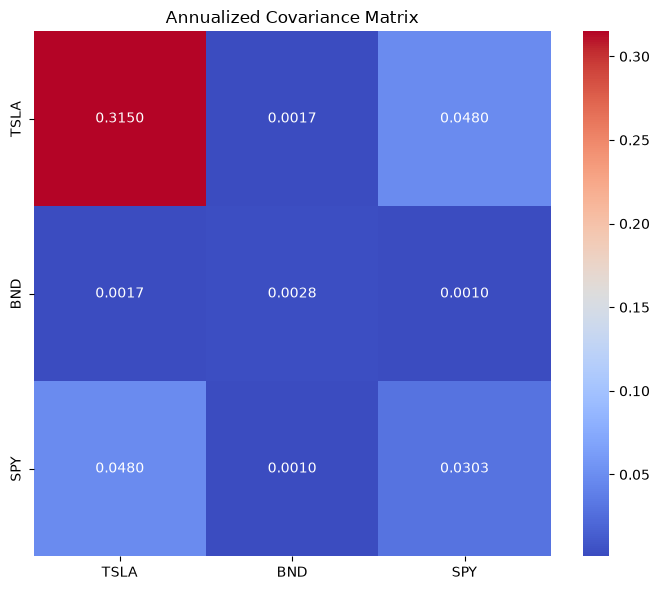

In [6]:
cov_matrix = returns[TICKERS].cov() * TRADING_DAYS   # annualized

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cov_matrix, annot=True, fmt=".4f", cmap="coolwarm", ax=ax)
ax.set_title("Annualized Covariance Matrix")
plt.tight_layout()
plt.savefig("../data/processed/fig_task4_covariance_heatmap.png", dpi=120)
plt.show()

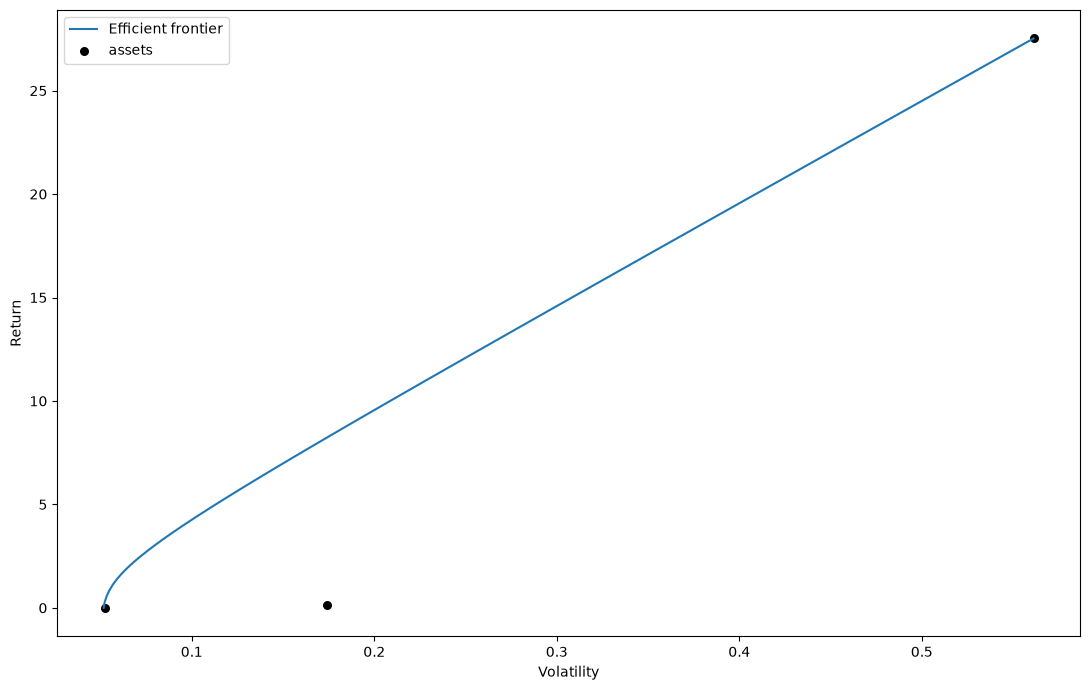

In [7]:
ef = EfficientFrontier(mu, cov_matrix)
fig, ax = plt.subplots(figsize=(11, 7))
plotting.plot_efficient_frontier(ef, ax=ax, show_assets=True)
plt.tight_layout()
plt.savefig("../data/processed/fig_task4_efficient_frontier.png", dpi=120)
plt.show()

In [8]:
ef_sharpe = EfficientFrontier(mu, cov_matrix)
weights_sharpe = ef_sharpe.max_sharpe()
cleaned_sharpe = ef_sharpe.clean_weights()
perf_sharpe = ef_sharpe.portfolio_performance(verbose=True)

print("\nMax Sharpe Ratio Portfolio weights:")
print(cleaned_sharpe)

Expected annual return: 2752.1%
Annual volatility: 56.1%
Sharpe Ratio: 49.04

Max Sharpe Ratio Portfolio weights:
OrderedDict({'TSLA': 1.0, 'BND': 0.0, 'SPY': 0.0})


In [9]:
ef_minvol = EfficientFrontier(mu, cov_matrix)
weights_minvol = ef_minvol.min_volatility()
cleaned_minvol = ef_minvol.clean_weights()
perf_minvol = ef_minvol.portfolio_performance(verbose=True)

print("\nMinimum Volatility Portfolio weights:")
print(cleaned_minvol)

Expected annual return: -0.1%
Annual volatility: 5.2%
Sharpe Ratio: -0.01

Minimum Volatility Portfolio weights:
OrderedDict({'TSLA': 0.0, 'BND': 0.94291, 'SPY': 0.05709})


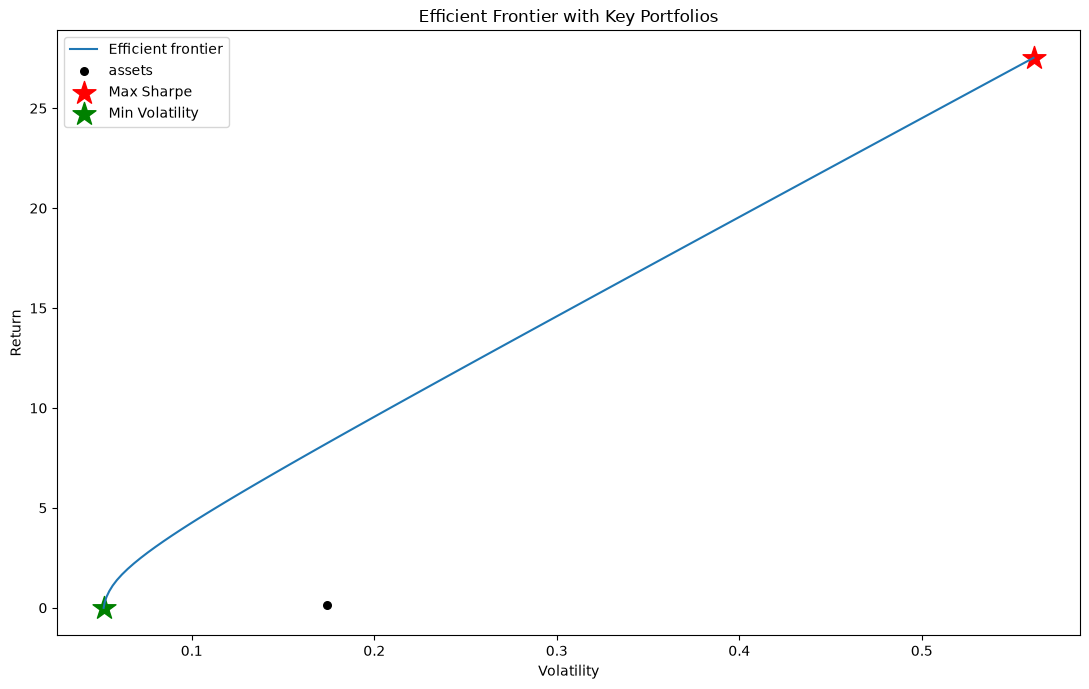

In [10]:
fig, ax = plt.subplots(figsize=(11, 7))
ef_plot = EfficientFrontier(mu, cov_matrix)
plotting.plot_efficient_frontier(ef_plot, ax=ax, show_assets=True)

ax.scatter(perf_sharpe[1], perf_sharpe[0], marker="*", s=300, c="red", label="Max Sharpe") # type: ignore
ax.scatter(perf_minvol[1], perf_minvol[0], marker="*", s=300, c="green", label="Min Volatility") # type: ignore
ax.legend()
ax.set_title("Efficient Frontier with Key Portfolios")
plt.tight_layout()
plt.savefig("../data/processed/fig_task4_frontier_with_portfolios.png", dpi=120)
plt.show()